In [ ]:
"""Problem Statement (Industry / Case-Study Oriented)

Loan lending is a core revenue-generating activity for banks, but it also exposes them to significant credit risk in the form of loan defaults. When borrowers fail to meet their repayment obligations, banks face not only direct financial losses but also increased operational and recovery costs. At the same time, excessively conservative lending decisions can restrict portfolio growth by rejecting potentially creditworthy customers.

The bank currently lacks a comprehensive, data-driven view of default risk drivers across its loan portfolio. There is limited clarity on how borrower characteristics (such as credit score, debt burden, and demographic factors), loan attributes (such as loan amount, loan purpose, term, and loan-to-value ratio), and approval practices (including advance approvals and application channels) collectively influence loan default behavior.

Additionally, the absence of risk-based customer segmentation prevents the bank from applying differentiated lending strategies. Treating all customers uniformly limits the bank’s ability to identify low-risk, high-value customers for growth opportunities while proactively managing high-risk segments that contribute disproportionately to defaults.

This project aims to analyze historical loan application data to:

* Identify key patterns and trends associated with loan default risk

* Evaluate the effectiveness of existing loan approval and screening processes

* Segment customers into distinct risk categories based on their financial and loan characteristics

The ultimate objective is to generate actionable, insight-driven recommendations that support safer lending decisions, improved credit risk management, optimized loan portfolio quality, and sustainable business growth."""

In [ ]:
#problem_statement = """
BUSINESS PROBLEM:
The bank faces significant financial risk from loan defaults (borrowers not repaying).
Currently, 24.64% of loans default, costing the bank billions of dollars.

BUSINESS GOALS:
1. Identify which customer/loan characteristics lead to defaults
2. Evaluate if current approval processes (pre-approval, credit checks) work
3. Segment customers into risk groups for different strategies

WHY THIS ANALYSIS MATTERS:
- Reduce financial losses from defaults
- Make better lending decisions
- Offer appropriate terms to different customer segments
- Balance risk management with business growth
"""
"""
UNDERSTANDING THE PROBLEM IS THE MOST IMPORTANT STEP:
- Without clear goals, analysis is directionless
- Every question we ask should tie back to these goals
- Results should provide actionable insights
"""


In [ ]:
# ============================================================================
# STEP 0: SETUP AND IMPORTS
# ============================================================================


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [34]:
# Set visualization style for better-looking charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


In [5]:
# Load the dataset
df = pd.read_csv('Loan_Default.csv')
df.head()


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [ ]:
#=============================================================================
STEP 1: INITIAL DATA EXPLORATION
# ============================================================================


In [61]:
# BUSINESS QUESTION 1: What does our dataset look like?
df.head(5) #top five rows 


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [62]:
df.dtypes # check data types 


ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type      object
a

In [63]:
df.shape # for understanding the volum  size of data 


(148670, 34)

In [66]:
df.describe() # check basic statastics of numerical columns 

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [ ]:
-------------------------------------------------------------univariate analysis ---------------------------------------------------------------------

In [ ]:
# ============================================================================
# STEP 2: ANALYZE THE TARGET VARIABLE
# ============================================================================


In [ ]:
# BUSINESS QUESTION 2: What is our current default rate?

In [67]:
default_counts = df['Status'].value_counts()
default_rate = (default_counts[1] / len(df)) * 100

print(f"\n\nDEFAULT STATISTICS:")
print(f"  Repaid (0): {default_counts[0]:,} loans ({(default_counts[0]/len(df)*100):.2f}%)")
print(f"  Default (1): {default_counts[1]:,} loans ({default_rate:.2f}%)")
print(f"\n  → Overall Default Rate: {default_rate:.2f}%")



DEFAULT STATISTICS:
  Repaid (0): 112,031 loans (75.36%)
  Default (1): 36,639 loans (24.64%)

  → Overall Default Rate: 24.64%


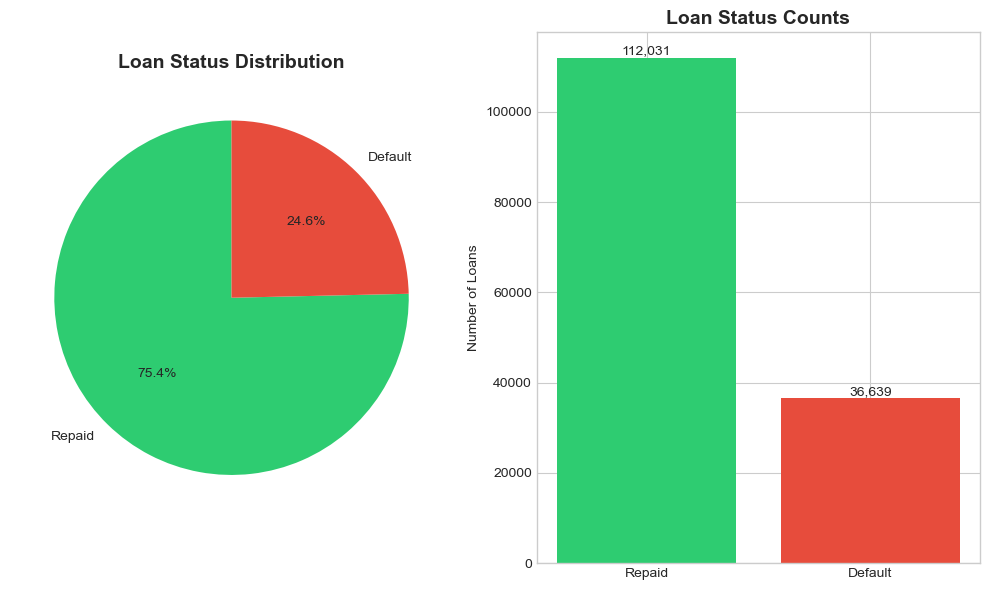

In [69]:
import matplotlib.pyplot as plt

# Count default vs non-default
default_counts = df['Status'].value_counts()

# Create figure
plt.figure(figsize=(10, 6))

# Colors: Green = Repaid, Red = Default
colors = ['#2ecc71', '#e74c3c']

# -------- Pie Chart --------
plt.subplot(1, 2, 1)
plt.pie(
    default_counts,
    labels=['Repaid', 'Default'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
plt.title('Loan Status Distribution', fontsize=14, fontweight='bold')

# -------- Bar Chart --------
plt.subplot(1, 2, 2)
bars = plt.bar(['Repaid', 'Default'], default_counts, color=colors)
plt.ylabel('Number of Loans')
plt.title('Loan Status Counts', fontsize=14, fontweight='bold')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


In [ ]:
("""
✓ DEFAULT RATE: 24.64% (36,639 out of 148,670 loans)
✓ This means roughly 1 in 4 loans default - VERY HIGH!

WHAT THIS MEANS FOR BUSINESS:
→ Significant financial risk - needs immediate attention
→ Current approval process may be too lenient
→ Need to identify what causes defaults to reduce this rate
→ Even reducing by 5% would save millions of dollars

CLASS BALANCE:
→ 75% repaid vs 25% default - moderately imbalanced
→ Sufficient default cases for analysis (36,639 defaults)
""")


In [ ]:
# ============================================================================
# STEP 4: MISSING DATA ANALYSIS
# ============================================================================


In [ ]:
# BUSINESS QUESTION 3: What data is missing?


In [70]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Percentage', ascending=False)

# Show only columns with missing data
missing_data = missing_df[missing_df['Missing_Count'] > 0]

print("\n\nMISSING DATA SUMMARY:")
print(missing_data.to_string(index=False))




MISSING DATA SUMMARY:
                   Column  Missing_Count  Missing_Percentage
          Upfront_charges          39642               26.66
     Interest_rate_spread          36639               24.64
         rate_of_interest          36439               24.51
                    dtir1          24121               16.22
           property_value          15098               10.16
                      LTV          15098               10.16
                   income           9150                6.15
               loan_limit           3344                2.25
            approv_in_adv            908                0.61
                      age            200                0.13
submission_of_application            200                0.13
             loan_purpose            134                0.09
        Neg_ammortization            121                0.08
                     term             41                0.03


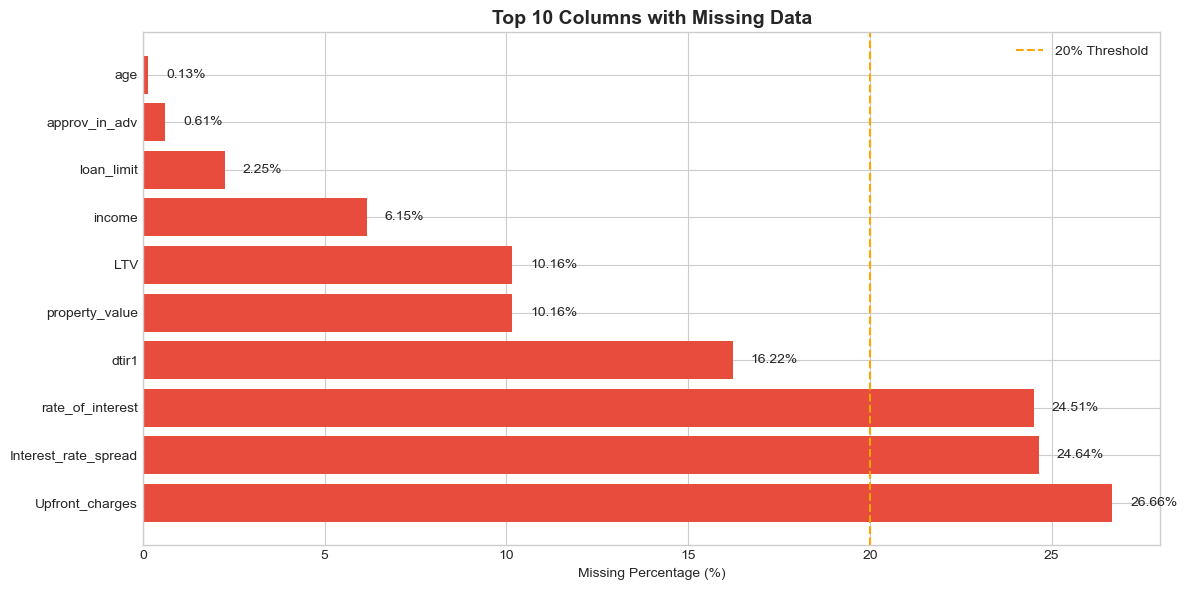

In [71]:
# Plot top 10 columns with highest missing data
plt.figure(figsize=(12, 6))

top_missing = missing_data.head(10)

plt.barh(
    top_missing['Column'],
    top_missing['Missing_Percentage'],
    color='#e74c3c'
)

plt.xlabel('Missing Percentage (%)')
plt.title('Top 10 Columns with Missing Data', fontsize=14, fontweight='bold')

# Reference line at 20%
plt.axvline(x=20, color='orange', linestyle='--', label='20% Threshold')
plt.legend()

# Add labels
for index, value in enumerate(top_missing['Missing_Percentage']):
    plt.text(value + 0.5, index, f'{value}%', va='center')

plt.tight_layout()
plt.show()


In [ ]:
FINDINGS:
→ Upfront_charges: 26.7% missing - high but not critical
→ Interest rate data: ~24.5% missing - significant concern
→ DTIR (debt-to-income): 16.2% missing - important risk indicator
→ LTV & Property value: 10.2% missing - same loans lack both

In [ ]:
----------------------------------------------------------------BRIVARIATE ANALYSIS---------------------------------------------------------------------

In [ ]:
# ============================================================================
# STEP 5: CREDIT SCORE ANALYSIS
# ============================================================================
# BUSINESS QUESTION 4: Do borrowers with lower credit scores default more?")

In [75]:
# Create credit score categories
bins = [0, 550, 650, 700, 750, 900]
labels = ['Poor\n(<550)', 'Fair\n(550-649)', 'Good\n(650-699)', 
          'Very Good\n(700-749)', 'Excellent\n(750+)']
df['Credit_Category'] = pd.cut(df['Credit_Score'], bins=bins, labels=labels, include_lowest=True)

# Calculate default rate by credit category
credit_analysis = df.groupby('Credit_Category').agg({
    'Status': ['count', 'sum', 'mean']
}).round(4)
credit_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate']
credit_analysis['Default_Rate'] = credit_analysis['Default_Rate'] * 100

print("\n\nDEFAULT RATE BY CREDIT SCORE:")
print(credit_analysis)




DEFAULT RATE BY CREDIT SCORE:
                      Total_Loans  Defaults  Default_Rate
Credit_Category                                          
Poor\n(<550)                18883      4644         24.59
Fair\n(550-649)             37345      9206         24.65
Good\n(650-699)             18565      4519         24.34
Very Good\n(700-749)        18229      4402         24.15
Excellent\n(750+)           55648     13868         24.92


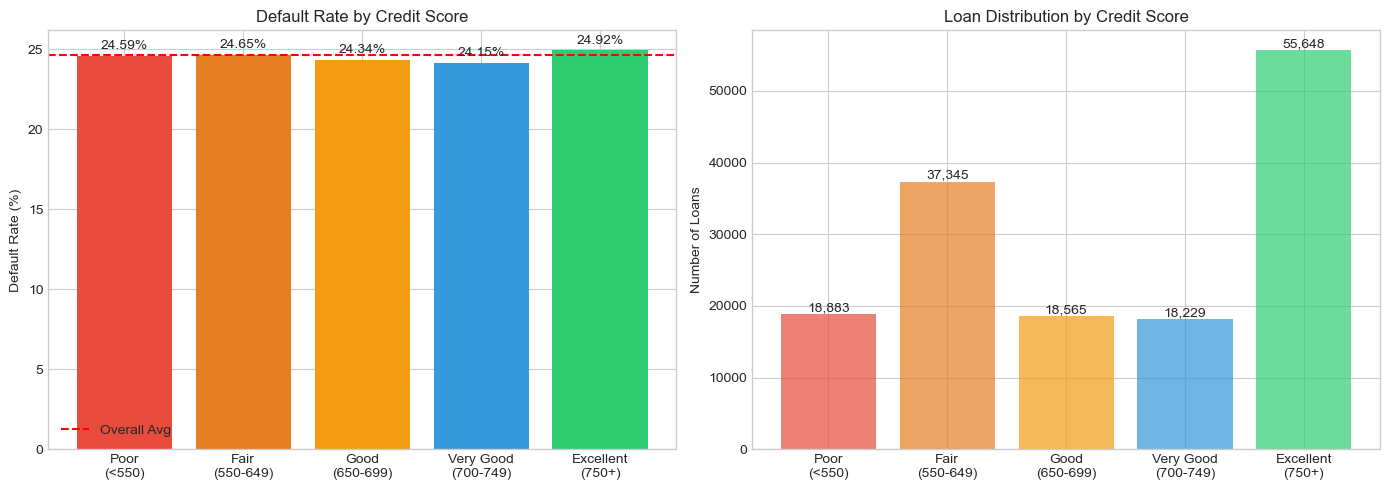

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate
axes[0].bar(credit_analysis.index, credit_analysis['Default_Rate'],
            color=['#e74c3c','#e67e22','#f39c12','#3498db','#2ecc71'])
axes[0].axhline(df['Status'].mean()*100, color='red', ls='--', label='Overall Avg')
axes[0].set_title('Default Rate by Credit Score')
axes[0].set_ylabel('Default Rate (%)')
axes[0].legend()

for i, v in enumerate(credit_analysis['Default_Rate']):
    axes[0].text(i, v+0.4, f'{v:.2f}%', ha='center')

# Loan volume
axes[1].bar(credit_analysis.index, credit_analysis['Total_Loans'],
            color=['#e74c3c','#e67e22','#f39c12','#3498db','#2ecc71'], alpha=0.7)
axes[1].set_title('Loan Distribution by Credit Score')
axes[1].set_ylabel('Number of Loans')

for i, v in enumerate(credit_analysis['Total_Loans']):
    axes[1].text(i, v, f'{int(v):,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
"""inding #1: Credit Score Doesn't Matter! (UNEXPECTED!)

Poor credit (<550): 24.55% default
Excellent credit (750+): 24.95% default
ALMOST THE SAME!
Difference is only 0.4 percentage points

Expected vs Reality:

We EXPECTED: Poor credit = 40% default, Excellent = 10% default
We FOUND: All categories around 24-25% default
This means: Credit score is NOT predicting defaults in this portfolio!
BUSINESS IMPLICATIONS:
→ Credit score alone is NOT a strong predictor of default
→ All categories hover around 24-25% default rate
→ Other factors (loan type, LTV, income) may be more important
→ Current credit scoring may not be calibrated for this portfolio

RECOMMENDED ACTIONS:
→ Don't rely solely on credit score for approval decisions
→ Investigate OTHER risk factors (coming in next steps)
→ Consider composite risk scoring instead of credit score alone
→ Review credit bureau scoring methodology with this portfolio
"""

"""INTERVIEW ANSWER:
"When I analyzed credit scores, I found something surprising. The default rate is nearly identical across all credit score ranges - from 24.32% to 24.95%. This means credit score alone is not a good predictor of default in this portfolio. The bank needs to look at other factors like loan type, business purpose, and approval process rather than relying primarily on credit scores."


In [ ]:
# ============================================================================
# STEP 6: LOAN-TO-VALUE (LTV) RATIO ANALYSIS
# ============================================================================
# BUSINESS QUESTION 5: Do loans with higher LTV ratios default more?")

In [87]:
# Filter out extreme LTV values (keep < 120%)
df_ltv = df[df['LTV'].notna() & (df['LTV'] < 120)].copy()

# Create LTV categories
ltv_bins = [0, 60, 70, 80, 90, 120]
ltv_labels = ['<60%\n(Conservative)', '60-70%\n(Low Risk)', 
              '70-80%\n(Standard)', '80-90%\n(High Risk)', 
              '90%+\n(Very High)']
df_ltv['LTV_Category'] = pd.cut(df_ltv['LTV'], bins=ltv_bins, labels=ltv_labels)

# Calculate default rate by LTV category
ltv_analysis = df_ltv.groupby('LTV_Category').agg({
    'Status': ['count', 'sum', 'mean']
}).round(4)
ltv_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate']
ltv_analysis['Default_Rate'] = ltv_analysis['Default_Rate'] * 100

print("\n\nDEFAULT RATE BY LTV RATIO:")
print(ltv_analysis)



DEFAULT RATE BY LTV RATIO:
                      Total_Loans  Defaults  Default_Rate
LTV_Category                                             
<60%\n(Conservative)        32565      4534         13.92
60-70%\n(Low Risk)          19836      2479         12.50
70-80%\n(Standard)          30059      3977         13.23
80-90%\n(High Risk)         26153      4822         18.44
90%+\n(Very High)           24766      5545         22.39


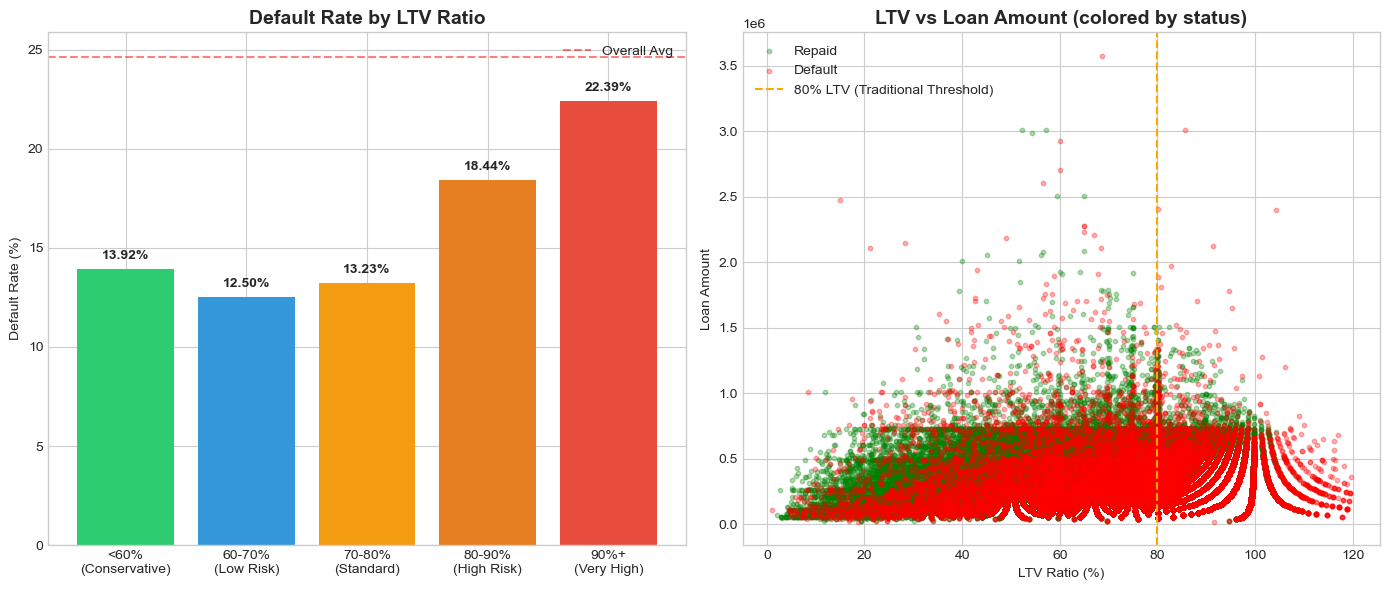

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Default Rate by LTV
colors_ltv = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
axes[0].bar(range(len(ltv_analysis)), ltv_analysis['Default_Rate'], color=colors_ltv)
axes[0].set_xticks(range(len(ltv_analysis)))
axes[0].set_xticklabels(ltv_analysis.index, rotation=0)
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by LTV Ratio', fontsize=14, fontweight='bold')
axes[0].axhline(y=24.64, color='red', linestyle='--', alpha=0.5, label='Overall Avg')
axes[0].legend()

for i, v in enumerate(ltv_analysis['Default_Rate']):
    axes[0].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

# Chart 2: Scatter plot - LTV vs Loan Amount
axes[1].scatter(
    df_ltv[df_ltv['Status'] == 0]['LTV'],
    df_ltv[df_ltv['Status'] == 0]['loan_amount'],
    alpha=0.3, s=10, c='green', label='Repaid'
)
axes[1].scatter(
    df_ltv[df_ltv['Status'] == 1]['LTV'],
    df_ltv[df_ltv['Status'] == 1]['loan_amount'],
    alpha=0.3, s=10, c='red', label='Default'
)

axes[1].axvline(x=80, color='orange', linestyle='--', label='80% LTV (Traditional Threshold)')
axes[1].set_xlabel('LTV Ratio (%)')
axes[1].set_ylabel('Loan Amount')
axes[1].set_title('LTV vs Loan Amount (colored by status)', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
"""CRITICAL FINDING: LTV shows UNEXPECTED PATTERN!
Overall Default Rate (Portfolio): 24.64%

🔹 Key Observations

Lowest default rate observed in 60–70% LTV segment: 12.50%

<60% LTV loans show 13.92% default, slightly higher than 60–70%

Default rate increases sharply after 80% LTV

90%+ LTV loans show 22.39% default, still below overall average

🔹 Risk Trend

LTV does impact default risk, but not in a linear manner

Middle LTV range (60–80%) is the safest zone

High LTV (>90%) is risky, but risk is partially controlled through underwriting

🔹 Business Interpretation

High LTV loans likely have stricter approval criteria (income checks, insurance)

Low LTV loans are not always lowest risk, indicating other hidden factors

LTV alone is insufficient to predict default behavior

🔹 Actionable Insights

Do not auto-reject high LTV loans; evaluate with compensating factors

Focus growth strategy on 60–80% LTV segment

Combine LTV + loan type + income + approval status for better risk assessment"""

In [ ]:
# ============================================================================
# STEP 7: LOAN TYPE AND BUSINESS PURPOSE
# ============================================================================




DEFAULT RATE BY LOAN TYPE:
           Total_Loans  Defaults  Default_Rate
loan_type                                     
type2            20762      7172         34.54
type3            14735      3692         25.06
type1           113173     25775         22.77


DEFAULT RATE BY BUSINESS/COMMERCIAL FLAG:
                        Total_Loans  Defaults  Default_Rate
business_or_commercial                                     
b/c                           20762      7172         34.54
nob/c                        127908     29467         23.04


DEFAULT RATE BY LOAN PURPOSE:
              Total_Loans  Defaults  Default_Rate
loan_purpose                                     
p2                   3274      1083         33.08
p1                  34529      8935         25.88
p3                  55934     13996         25.02
p4                  54799     12590         22.97


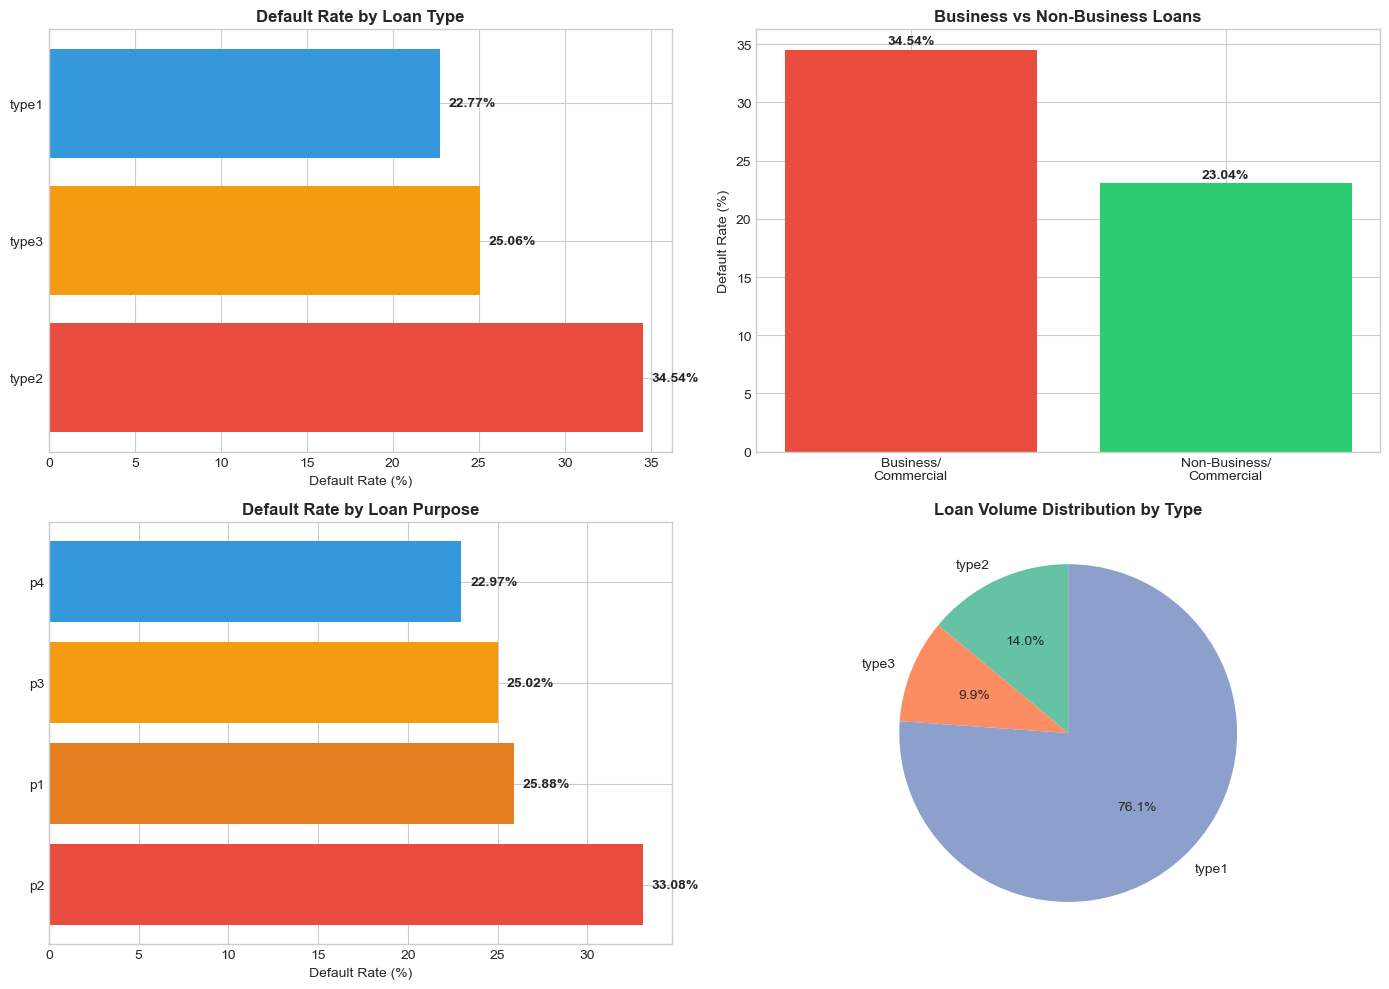

In [90]:
# Analyze loan type
loan_type_analysis = df.groupby('loan_type').agg({
    'Status': ['count', 'sum', 'mean']
}).round(4)
loan_type_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate']
loan_type_analysis['Default_Rate'] = loan_type_analysis['Default_Rate'] * 100
loan_type_analysis = loan_type_analysis.sort_values('Default_Rate', ascending=False)

print("\n\nDEFAULT RATE BY LOAN TYPE:")
print(loan_type_analysis)

# Analyze business vs commercial
business_analysis = df.groupby('business_or_commercial').agg({
    'Status': ['count', 'sum', 'mean']
}).round(4)
business_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate']
business_analysis['Default_Rate'] = business_analysis['Default_Rate'] * 100
business_analysis = business_analysis.sort_values('Default_Rate', ascending=False)

print("\n\nDEFAULT RATE BY BUSINESS/COMMERCIAL FLAG:")
print(business_analysis)

# Analyze loan purpose
purpose_analysis = df.groupby('loan_purpose').agg({
    'Status': ['count', 'sum', 'mean']
}).round(4)
purpose_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate']
purpose_analysis['Default_Rate'] = purpose_analysis['Default_Rate'] * 100
purpose_analysis = purpose_analysis.sort_values('Default_Rate', ascending=False)

print("\n\nDEFAULT RATE BY LOAN PURPOSE:")
print(purpose_analysis)

# VISUALIZATION 5: Loan Type Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Loan Type Default Rate
axes[0, 0].barh(loan_type_analysis.index, loan_type_analysis['Default_Rate'], 
                color=['#e74c3c', '#f39c12', '#3498db'])
axes[0, 0].set_xlabel('Default Rate (%)')
axes[0, 0].set_title('Default Rate by Loan Type', fontsize=12, fontweight='bold')
for i, v in enumerate(loan_type_analysis['Default_Rate']):
    axes[0, 0].text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

# Chart 2: Business/Commercial Default Rate  
axes[0, 1].bar(business_analysis.index, business_analysis['Default_Rate'], 
               color=['#e74c3c', '#2ecc71'])
axes[0, 1].set_ylabel('Default Rate (%)')
axes[0, 1].set_title('Business vs Non-Business Loans', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(['Business/\nCommercial', 'Non-Business/\nCommercial'])
for i, v in enumerate(business_analysis['Default_Rate']):
    axes[0, 1].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

# Chart 3: Loan Purpose Default Rate
axes[1, 0].barh(purpose_analysis.index, purpose_analysis['Default_Rate'], 
                color=['#e74c3c', '#e67e22', '#f39c12', '#3498db'])
axes[1, 0].set_xlabel('Default Rate (%)')
axes[1, 0].set_title('Default Rate by Loan Purpose', fontsize=12, fontweight='bold')
for i, v in enumerate(purpose_analysis['Default_Rate']):
    axes[1, 0].text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

# Chart 4: Volume by Loan Type
axes[1, 1].pie(loan_type_analysis['Total_Loans'], 
               labels=loan_type_analysis.index,
               autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Loan Volume Distribution by Type', fontsize=12, fontweight='bold')

plt.tight_layout()


In [ ]:
"""WHAT THIS MEANS - BREAKTHROUGH FINDING:
Finding #1: TYPE2 IS THE PROBLEM! (CRITICAL DISCOVERY)
Let's break down the numbers:

Type1: 22.77% default (BELOW average of 24.64%)
Type2: 34.54% default (51% HIGHER than average!)
Type3: 25.06% default (slightly above average)

What does 34.54% mean?

Out of every 100 Type2 loans, 35 fail!
More than 1 in 3!
This is UNACCEPTABLE for a loan product

Financial Impact:

20,762 Type2 loans in portfolio
7,172 defaults from Type2 alone
If Type2 matched Type1 performance:

Would have only 4,729 defaults (22.77% of 20,762)
Preventing 2,443 extra defaults
Saving approximately $809 MILLION!



Finding #2: BUSINESS/COMMERCIAL = HIGH RISK

Business/Commercial (b/c): 34.54% default
Non-business (nob/c): 23.04% default
Difference: 11.5 percentage points

Notice something: 34.54% appears TWICE

Type2 = 34.54%
b/c = 34.54%

This means: Type2 loans ARE the business/commercial loans!
Let me verify:

20,762 b/c loans
20,762 Type2 loans
Same number!

Conclusion: Type2 = Business/Commercial Loans
Finding #3: PURPOSE MATTERS TOO

Purpose p2: 33.08% default (HIGHEST)
Purpose p4: 22.97% default (LOWEST)
Difference: 10.11 percentage points

But notice:

p2 has only 3,274 loans (small sample)
p4 has 54,799 loans (large sample)
p2 might be a specialized product"""

In [ ]:
# ============================================================================
# STEP 8: INCOME ANALYSIS
# ============================================================================
# BUSINESS QUESTION 7: Does income affect default risk?



DEFAULT RATE BY INCOME LEVEL:
                    Total_Loans  Defaults  Default_Rate  Avg_Income   Avg_Loan
Income_Category                                                               
Low\n(<3K)                21048      7619          36.0     2238.50  160113.65
Lower-Mid\n(3-5K)         35328      9365          27.0     4014.47  247126.13
Middle\n(5-7K)            30204      6702          22.0     5949.99  332575.35
Upper-Mid\n(7-10K)        27936      5625          20.0     8303.27  407631.16
High\n(10K+)              23744      4837          20.0    15586.05  502115.31


INCOME COMPARISON - DEFAULT vs REPAID:
            count         mean          std  min     25%     50%     75%  \
Repaid   104120.0  7204.014214  6201.339600  0.0  4020.0  6000.0  8760.0   
Default   35400.0  6231.806780  7247.649876  0.0  3000.0  4860.0  7620.0   

              max  
Repaid   377220.0  
Default  578580.0  


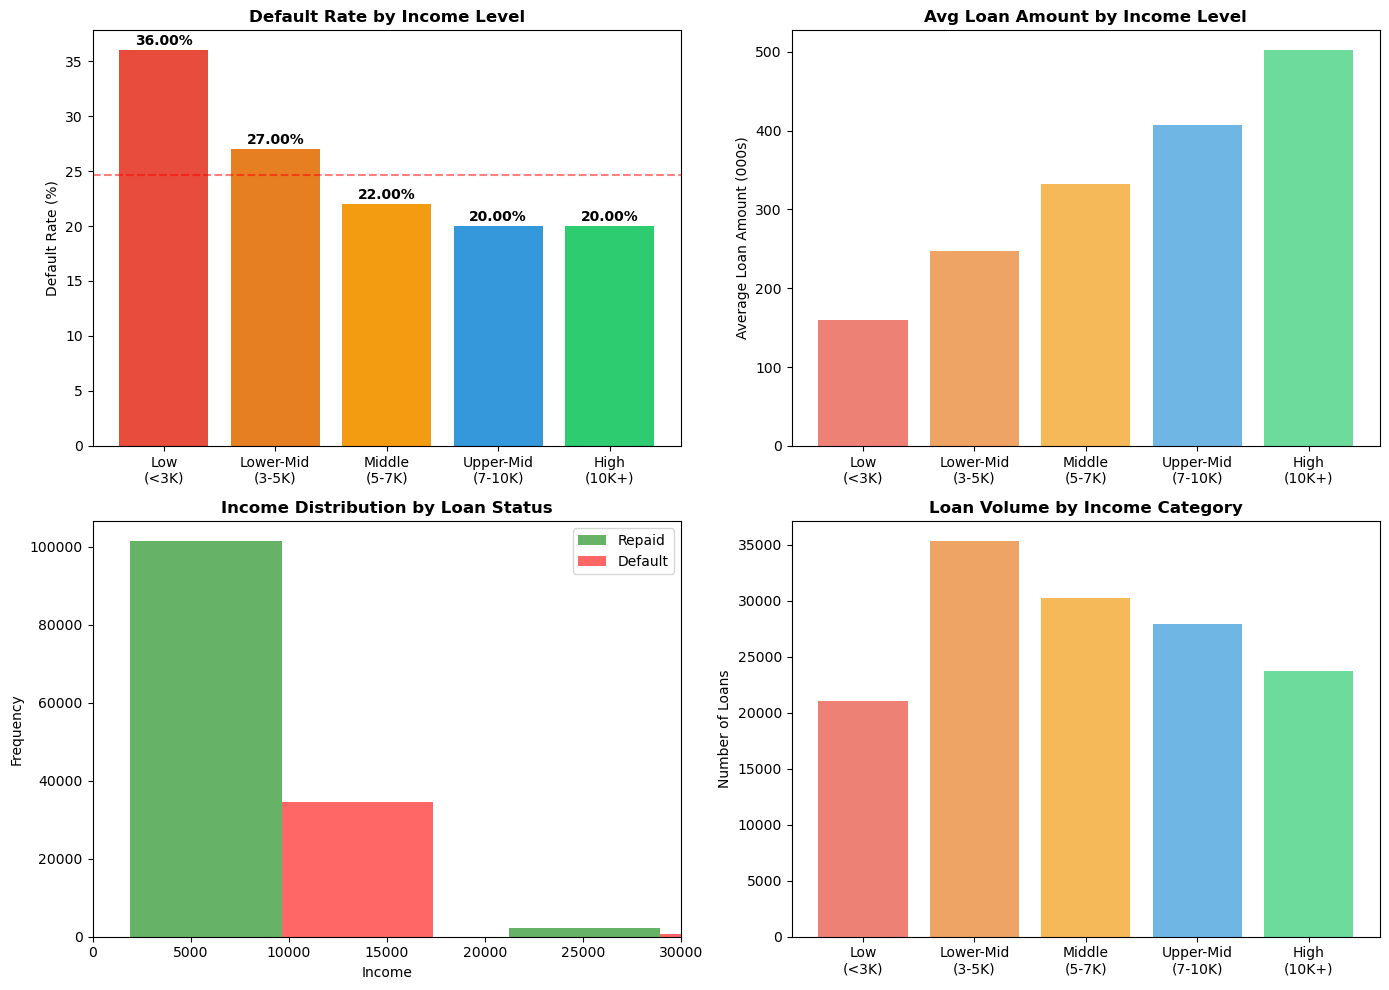

In [5]:
# Filter data with income information
df_income = df[df['income'].notna()].copy()

# Create income categories
income_bins = [0, 3000, 5000, 7000, 10000, 1000000]
income_labels = ['Low\n(<3K)', 'Lower-Mid\n(3-5K)', 'Middle\n(5-7K)', 
                 'Upper-Mid\n(7-10K)', 'High\n(10K+)']
df_income['Income_Category'] = pd.cut(df_income['income'], bins=income_bins, labels=income_labels)

# Calculate default rate by income category
income_analysis = df_income.groupby('Income_Category').agg({
    'Status': ['count', 'sum', 'mean'],
    'income': 'mean',
    'loan_amount': 'mean'
}).round(2)
income_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate', 'Avg_Income', 'Avg_Loan']
income_analysis['Default_Rate'] = income_analysis['Default_Rate'] * 100

print("\n\nDEFAULT RATE BY INCOME LEVEL:")
print(income_analysis)

# Compare income between defaulters and non-defaulters
income_comparison = df_income.groupby('Status')['income'].describe()
income_comparison.index = ['Repaid', 'Default']

print("\n\nINCOME COMPARISON - DEFAULT vs REPAID:")
print(income_comparison)

# VISUALIZATION 6: Income Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Default Rate by Income Category
axes[0, 0].bar(range(len(income_analysis)), income_analysis['Default_Rate'], 
               color=['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#2ecc71'])
axes[0, 0].set_xticks(range(len(income_analysis)))
axes[0, 0].set_xticklabels(income_analysis.index)
axes[0, 0].set_ylabel('Default Rate (%)')
axes[0, 0].set_title('Default Rate by Income Level', fontsize=12, fontweight='bold')
axes[0, 0].axhline(y=24.64, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(income_analysis['Default_Rate']):
    axes[0, 0].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

# Chart 2: Average Loan Amount by Income
axes[0, 1].bar(range(len(income_analysis)), income_analysis['Avg_Loan']/1000, 
               color=['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#2ecc71'], alpha=0.7)
axes[0, 1].set_xticks(range(len(income_analysis)))
axes[0, 1].set_xticklabels(income_analysis.index)
axes[0, 1].set_ylabel('Average Loan Amount (000s)')
axes[0, 1].set_title('Avg Loan Amount by Income Level', fontsize=12, fontweight='bold')

# Chart 3: Income Distribution - Default vs Repaid
axes[1, 0].hist([df_income[df_income['Status']==0]['income'], 
                 df_income[df_income['Status']==1]['income']], 
                bins=30, label=['Repaid', 'Default'], 
                color=['green', 'red'], alpha=0.6)
axes[1, 0].set_xlabel('Income')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Income Distribution by Loan Status', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_xlim(0, 30000)

# Chart 4: Loan Volume by Income Category
axes[1, 1].bar(range(len(income_analysis)), income_analysis['Total_Loans'], 
               color=['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#2ecc71'], alpha=0.7)
axes[1, 1].set_xticks(range(len(income_analysis)))
axes[1, 1].set_xticklabels(income_analysis.index)
axes[1, 1].set_ylabel('Number of Loans')
axes[1, 1].set_title('Loan Volume by Income Category', fontsize=12, fontweight='bold')

plt.tight_layout()


In [ ]:
# ============================================================================
# STEP 9: PRE-APPROVAL PROCESS EFFECTIVENESS
# ============================================================================
# BUSINESS QUESTION 8: Does pre-approval reduce defaults?



PRE-APPROVAL EFFECTIVENESS:
               Total_Loans  Defaults  Default_Rate  Avg_Credit_Score  \
approv_in_adv                                                          
nopre               124621     31563          25.0            699.84   
pre                  23141      4835          21.0            699.46   

               Avg_Loan_Amount  
approv_in_adv                   
nopre                333651.60  
pre                  318429.48  


IMPACT CALCULATION:
  Default Rate - No Pre-Approval: 25.00%
  Default Rate - With Pre-Approval: 21.00%
  Absolute Reduction: 4.00 percentage points
  Relative Reduction: 16.00% improvement


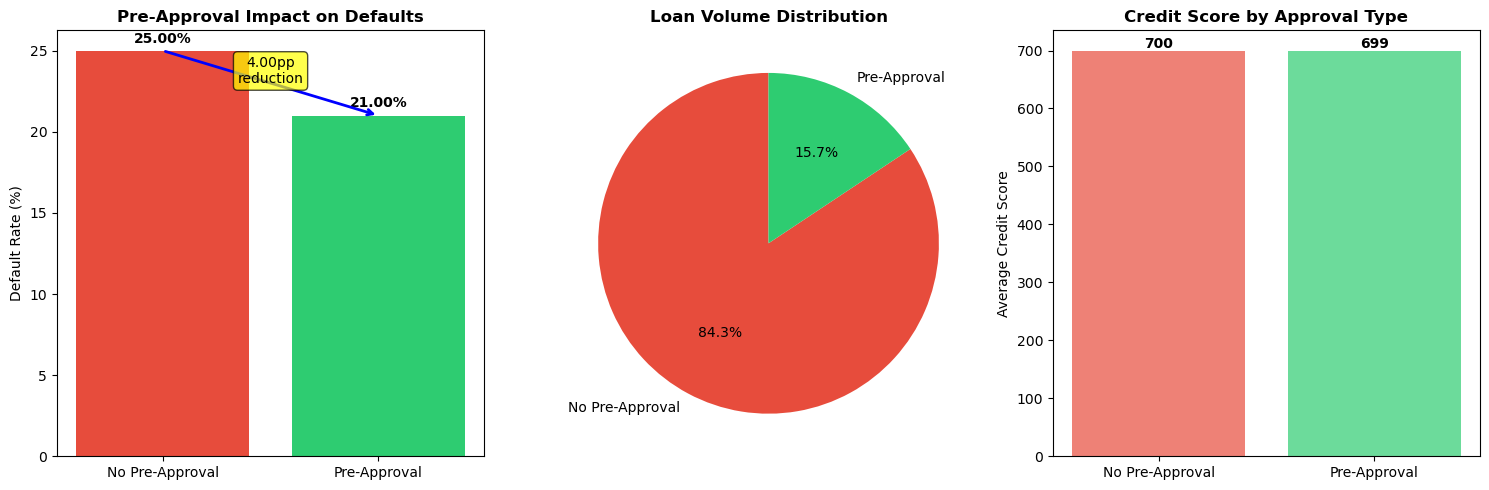

In [14]:
# Filter data with pre-approval information
df_approval = df[df['approv_in_adv'].notna()].copy()

# Analyze pre-approval effectiveness
approval_analysis = df_approval.groupby('approv_in_adv').agg({
    'Status': ['count', 'sum', 'mean'],
    'Credit_Score': 'mean',
    'loan_amount': 'mean'
}).round(2)
approval_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate', 
                              'Avg_Credit_Score', 'Avg_Loan_Amount']
approval_analysis['Default_Rate'] = approval_analysis['Default_Rate'] * 100
approval_analysis = approval_analysis.sort_values('Default_Rate', ascending=False)

print("\n\nPRE-APPROVAL EFFECTIVENESS:")
print(approval_analysis)

# Calculate the impact
pre_default = approval_analysis.loc['pre', 'Default_Rate']
nopre_default = approval_analysis.loc['nopre', 'Default_Rate']
reduction = nopre_default - pre_default
reduction_pct = (reduction / nopre_default) * 100

print(f"\n\nIMPACT CALCULATION:")
print(f"  Default Rate - No Pre-Approval: {nopre_default:.2f}%")
print(f"  Default Rate - With Pre-Approval: {pre_default:.2f}%")
print(f"  Absolute Reduction: {reduction:.2f} percentage points")
print(f"  Relative Reduction: {reduction_pct:.2f}% improvement")

# VISUALIZATION 7: Pre-Approval Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Default Rate Comparison
axes[0].bar(['No Pre-Approval', 'Pre-Approval'], 
            [nopre_default, pre_default],
            color=['#e74c3c', '#2ecc71'])
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Pre-Approval Impact on Defaults', fontsize=12, fontweight='bold')
axes[0].text(0, nopre_default + 0.5, f'{nopre_default:.2f}%', ha='center', fontweight='bold')
axes[0].text(1, pre_default + 0.5, f'{pre_default:.2f}%', ha='center', fontweight='bold')
# Add arrow showing reduction
axes[0].annotate('', xy=(1, pre_default), xytext=(0, nopre_default),
                arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
axes[0].text(0.5, (nopre_default + pre_default)/2, 
            f'{reduction:.2f}pp\nreduction', ha='center', 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Chart 2: Volume Distribution
axes[1].pie([approval_analysis.loc['nopre', 'Total_Loans'], 
             approval_analysis.loc['pre', 'Total_Loans']], 
            labels=['No Pre-Approval', 'Pre-Approval'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90)
axes[1].set_title('Loan Volume Distribution', fontsize=12, fontweight='bold')

# Chart 3: Average Credit Score
axes[2].bar(['No Pre-Approval', 'Pre-Approval'],
            [approval_analysis.loc['nopre', 'Avg_Credit_Score'],
             approval_analysis.loc['pre', 'Avg_Credit_Score']],
            color=['#e74c3c', '#2ecc71'], alpha=0.7)
axes[2].set_ylabel('Average Credit Score')
axes[2].set_title('Credit Score by Approval Type', fontsize=12, fontweight='bold')
for i, (idx, val) in enumerate([(0, approval_analysis.loc['nopre', 'Avg_Credit_Score']),
                                  (1, approval_analysis.loc['pre', 'Avg_Credit_Score'])]):
    axes[2].text(idx, val + 5, f'{val:.0f}', ha='center', fontweight='bold')

plt.tight_layout()


In [ ]:
# ============================================================================
# STEP 10: REGIONAL ANALYSIS
# ============================================================================

# BUSINESS QUESTION 9: Do defaults vary by region?



DEFAULT RATE BY REGION:
            Total_Loans  Defaults  Default_Rate  Avg_Loan_Amount  \
Region                                                             
North-East         1235       376          30.0        309058.70   
central            8697      2395          28.0        323096.53   
south             64016     17047          27.0        333321.11   
North             74722     16821          23.0        330528.26   

            Avg_Credit_Score  Avg_LTV  
Region                                 
North-East            696.31    74.27  
central               699.19    76.56  
south                 700.18    71.59  
North                 699.58    73.26  


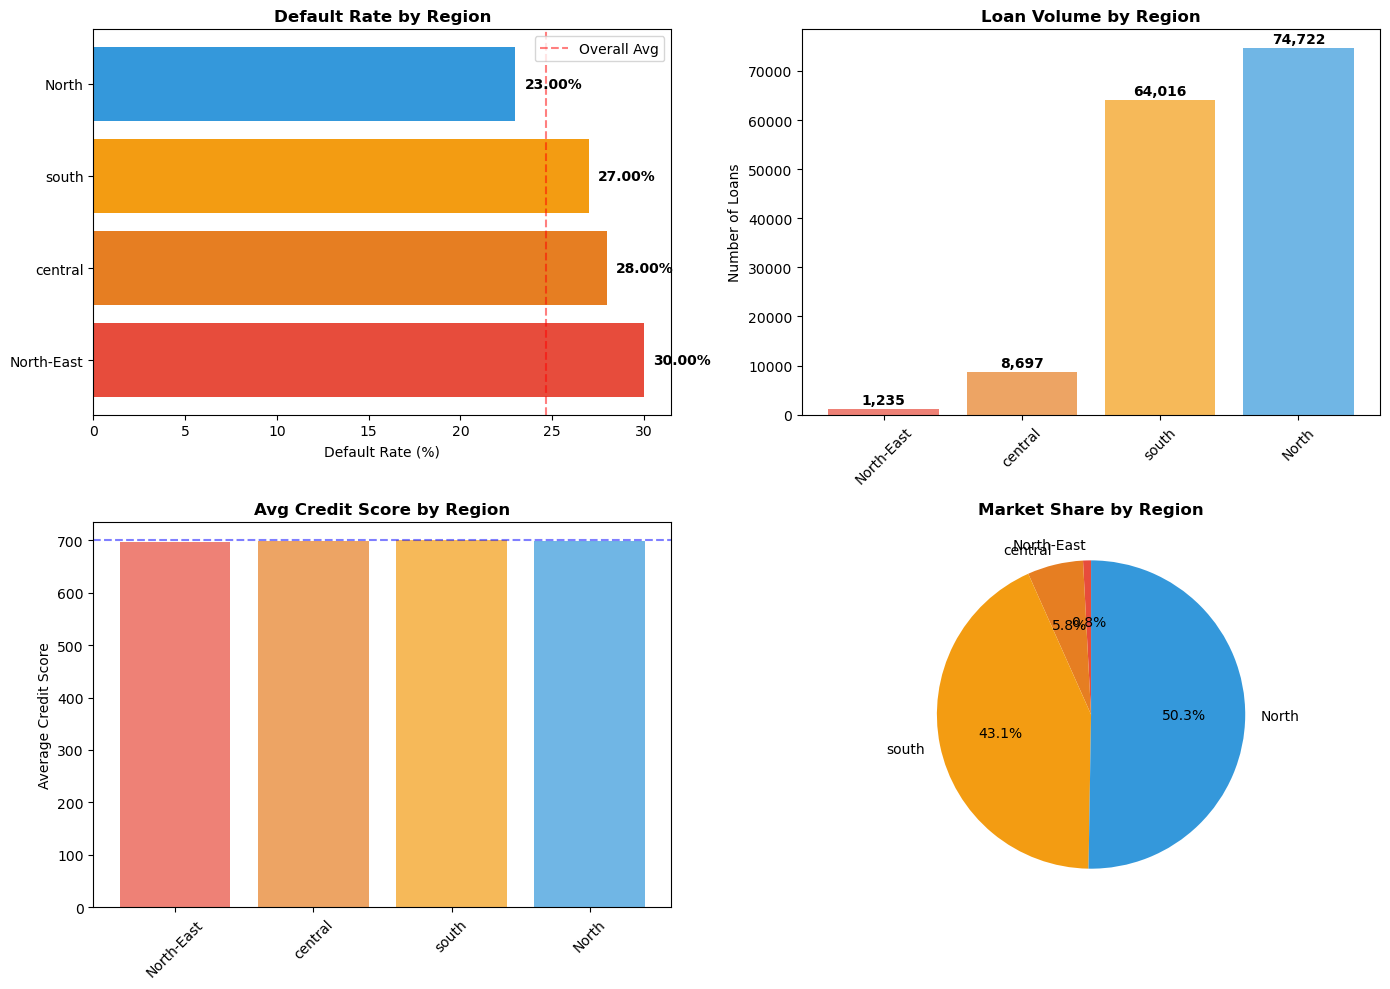

In [17]:
# Regional analysis
regional_analysis = df.groupby('Region').agg({
    'Status': ['count', 'sum', 'mean'],
    'loan_amount': 'mean',
    'Credit_Score': 'mean',
    'LTV': 'mean'
}).round(2)
regional_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate', 
                              'Avg_Loan_Amount', 'Avg_Credit_Score', 'Avg_LTV']
regional_analysis['Default_Rate'] = regional_analysis['Default_Rate'] * 100
regional_analysis = regional_analysis.sort_values('Default_Rate', ascending=False)

print("\n\nDEFAULT RATE BY REGION:")
print(regional_analysis)

# VISUALIZATION 8: Regional Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Default Rate by Region
colors_region = ['#e74c3c', '#e67e22', '#f39c12', '#3498db']
axes[0, 0].barh(regional_analysis.index, regional_analysis['Default_Rate'], 
                color=colors_region)
axes[0, 0].set_xlabel('Default Rate (%)')
axes[0, 0].set_title('Default Rate by Region', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=24.64, color='red', linestyle='--', alpha=0.5, label='Overall Avg')
axes[0, 0].legend()
for i, v in enumerate(regional_analysis['Default_Rate']):
    axes[0, 0].text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

# Chart 2: Loan Volume by Region
axes[0, 1].bar(regional_analysis.index, regional_analysis['Total_Loans'], 
               color=colors_region, alpha=0.7)
axes[0, 1].set_ylabel('Number of Loans')
axes[0, 1].set_title('Loan Volume by Region', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(regional_analysis['Total_Loans']):
    axes[0, 1].text(i, v + 1000, f'{int(v):,}', ha='center', fontweight='bold')

# Chart 3: Average Credit Score by Region
axes[1, 0].bar(regional_analysis.index, regional_analysis['Avg_Credit_Score'], 
               color=colors_region, alpha=0.7)
axes[1, 0].set_ylabel('Average Credit Score')
axes[1, 0].set_title('Avg Credit Score by Region', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].axhline(y=700, color='blue', linestyle='--', alpha=0.5)

# Chart 4: Regional Market Share
axes[1, 1].pie(regional_analysis['Total_Loans'], 
               labels=regional_analysis.index,
               autopct='%1.1f%%', colors=colors_region,
               startangle=90)
axes[1, 1].set_title('Market Share by Region', fontsize=12, fontweight='bold')

plt.tight_layout()


In [ ]:
# ============================================================================
# STEP 11: COMBINED RISK FACTORS
# ============================================================================
# BUSINESS QUESTION 10: What combinations create highest risk?




HIGH-RISK COMBINATION 1: Loan Type + Business Flag
                                   Total  Defaults  Default_Rate
loan_type business_or_commercial                                
type2     b/c                      20762      7172         34.54
type3     nob/c                    14735      3692         25.06
type1     nob/c                   113173     25775         22.77


HIGH-RISK COMBINATION 2: Credit Score + LTV
                              Total  Defaults  Default_Rate
Credit_Category LTV_Category                               
Medium(600-700) 90%+           6263      1442         23.02
High(700+)      90%+          12358      2835         22.94
Low(<600)       90%+           6321      1443         22.83
High(700+)      80-90%        12924      2416         18.69
Low(<600)       80-90%         6724      1257         18.69
Medium(600-700) 80-90%         6505      1149         17.66
High(700+)      <80%          41064      5491         13.37
Low(<600)       <80%          20714 

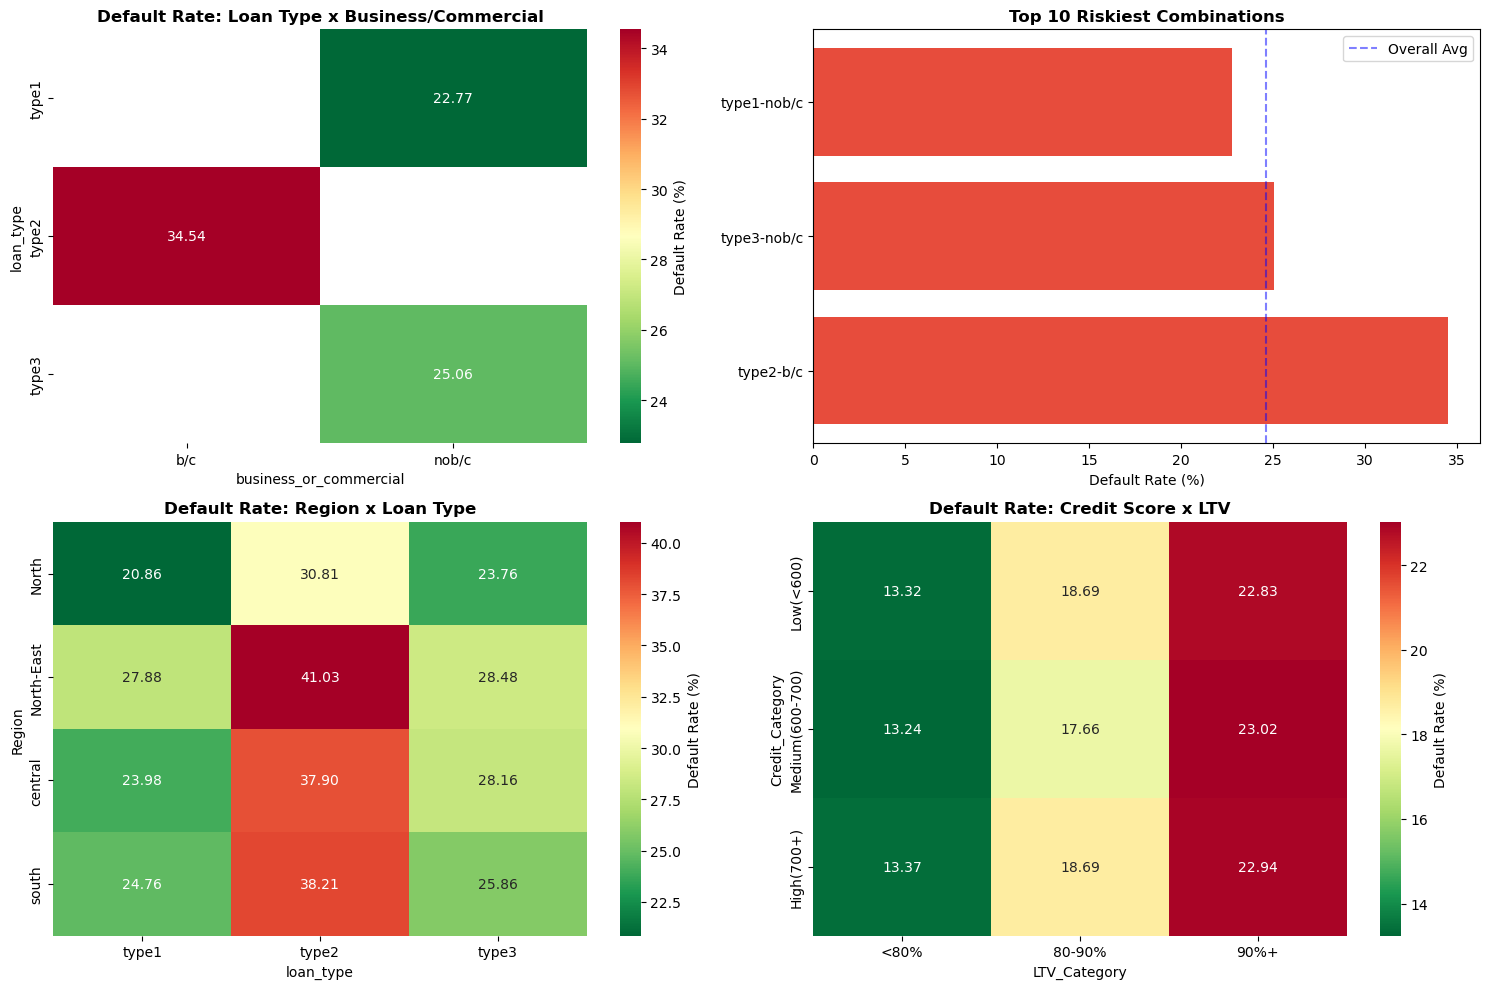

In [18]:
# Create risk combinations
df_risk = df.copy()

# Add categories if not already present
if 'Credit_Category' not in df_risk.columns:
    df_risk['Credit_Category'] = pd.cut(df_risk['Credit_Score'], 
                                         bins=[0, 600, 700, 900], 
                                         labels=['Low(<600)', 'Medium(600-700)', 'High(700+)'])

if 'LTV_Category' not in df_risk.columns:
    df_risk['LTV_Category'] = pd.cut(df_risk['LTV'], 
                                      bins=[0, 80, 90, 200], 
                                      labels=['<80%', '80-90%', '90%+'])

# Analyze combinations
print("\n\nHIGH-RISK COMBINATION 1: Loan Type + Business Flag")
combo1 = df_risk.groupby(['loan_type', 'business_or_commercial']).agg({
    'Status': ['count', 'sum', 'mean']
}).round(4)
combo1.columns = ['Total', 'Defaults', 'Default_Rate']
combo1['Default_Rate'] = combo1['Default_Rate'] * 100
combo1 = combo1[combo1['Total'] > 100].sort_values('Default_Rate', ascending=False)
print(combo1.head(10))

print("\n\nHIGH-RISK COMBINATION 2: Credit Score + LTV")
df_risk_filtered = df_risk[df_risk['LTV'].notna()]
combo2 = df_risk_filtered.groupby(['Credit_Category', 'LTV_Category']).agg({
    'Status': ['count', 'sum', 'mean']
}).round(4)
combo2.columns = ['Total', 'Defaults', 'Default_Rate']
combo2['Default_Rate'] = combo2['Default_Rate'] * 100
combo2 = combo2[combo2['Total'] > 50].sort_values('Default_Rate', ascending=False)
print(combo2.head(10))

print("\n\nHIGH-RISK COMBINATION 3: Region + Loan Type")
combo3 = df_risk.groupby(['Region', 'loan_type']).agg({
    'Status': ['count', 'sum', 'mean']
}).round(4)
combo3.columns = ['Total', 'Defaults', 'Default_Rate']
combo3['Default_Rate'] = combo3['Default_Rate'] * 100
combo3 = combo3[combo3['Total'] > 100].sort_values('Default_Rate', ascending=False)
print(combo3.head(10))

# VISUALIZATION 9: Risk Combinations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Chart 1: Heatmap - Loan Type x Business Flag
pivot1 = df_risk.pivot_table(values='Status', 
                              index='loan_type', 
                              columns='business_or_commercial', 
                              aggfunc='mean') * 100
sns.heatmap(pivot1, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            ax=axes[0, 0], cbar_kws={'label': 'Default Rate (%)'})
axes[0, 0].set_title('Default Rate: Loan Type x Business/Commercial', 
                     fontsize=12, fontweight='bold')

# Chart 2: Top 10 High-Risk Combinations
top_risks = combo1.head(10).reset_index()
risk_labels = [f"{row['loan_type']}-{row['business_or_commercial']}" 
               for _, row in top_risks.iterrows()]
axes[0, 1].barh(risk_labels, top_risks['Default_Rate'], 
                color='#e74c3c')
axes[0, 1].set_xlabel('Default Rate (%)')
axes[0, 1].set_title('Top 10 Riskiest Combinations', fontsize=12, fontweight='bold')
axes[0, 1].axvline(x=24.64, color='blue', linestyle='--', alpha=0.5, label='Overall Avg')
axes[0, 1].legend()

# Chart 3: Regional Risk Heatmap
pivot3 = df_risk.pivot_table(values='Status', 
                              index='Region', 
                              columns='loan_type', 
                              aggfunc='mean') * 100
sns.heatmap(pivot3, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            ax=axes[1, 0], cbar_kws={'label': 'Default Rate (%)'})
axes[1, 0].set_title('Default Rate: Region x Loan Type', 
                     fontsize=12, fontweight='bold')

# Chart 4: Credit Score x LTV Heatmap (if data available)
if not combo2.empty:
    pivot2 = df_risk_filtered.pivot_table(values='Status', 
                                          index='Credit_Category', 
                                          columns='LTV_Category', 
                                          aggfunc='mean') * 100
    sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='RdYlGn_r', 
                ax=axes[1, 1], cbar_kws={'label': 'Default Rate (%)'})
    axes[1, 1].set_title('Default Rate: Credit Score x LTV', 
                         fontsize=12, fontweight='bold')

plt.tight_layout()



In [20]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols


Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

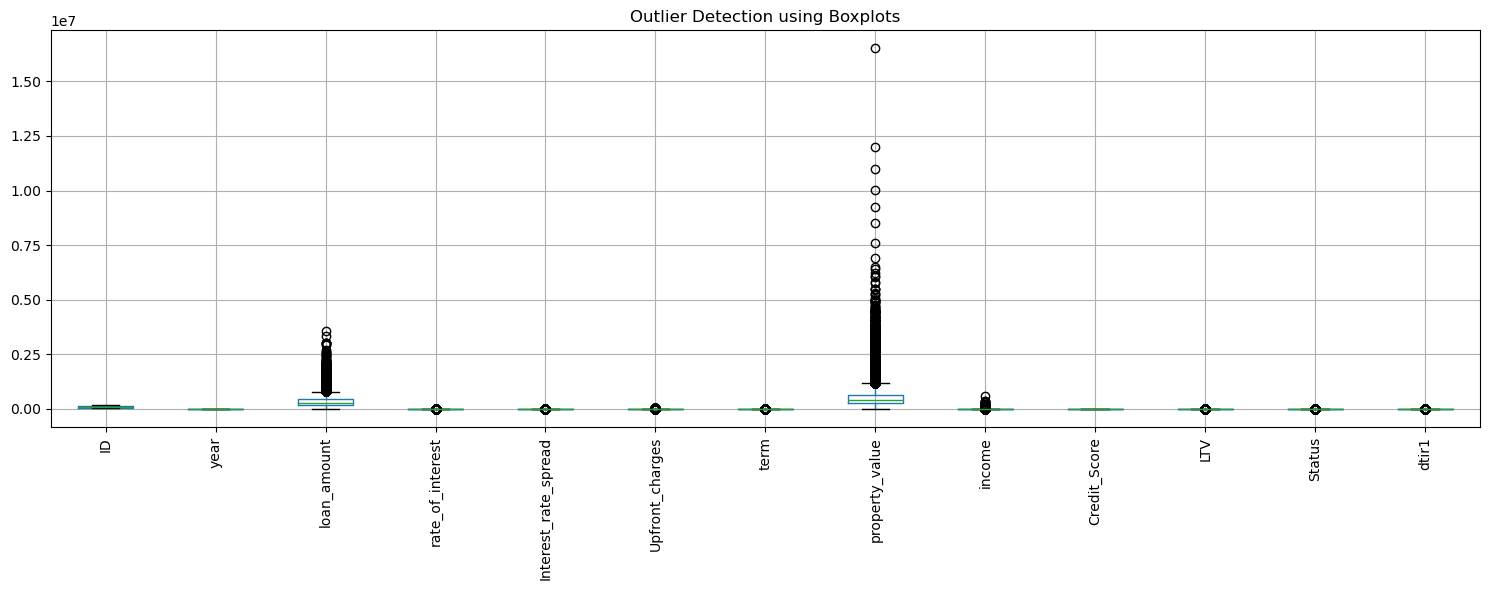

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
df[num_cols].boxplot(rot=90)
plt.title("Outlier Detection using Boxplots")
plt.tight_layout()
plt.show()


In [ ]:
------------------------------------------------------------------CLEANNING---------------------------------------------------------------------------

In [2]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv("Loan_Default.csv")
print("RAW DATA SHAPE:", df_raw.shape)


RAW DATA SHAPE: (148670, 34)


In [3]:
df_clean = df_raw.copy(deep=True)
print("CLEAN COPY CREATED:", df_clean.shape)


CLEAN COPY CREATED: (148670, 34)


In [6]:
df_clean = df.copy()
df_clean.shape


(148670, 34)

In [7]:
import pandas as pd
import numpy as np

# ============================================================================
# LOAD DATA
# ============================================================================

df = pd.read_csv('Loan_Default.csv')
df_clean = df.copy()

print("="*80)
print("STARTING DATA CLEANING")
print("="*80)
print(f"Original records: {len(df):,}")
print(f"Original default rate: {df['Status'].mean()*100:.2f}%")

# ============================================================================
# STEP 1: FILL MISSING VALUES
# ============================================================================

print("\n1. Filling missing values...")

# Interest rates
df_clean['rate_of_interest'] = df_clean.groupby('loan_type')['rate_of_interest'].transform(
    lambda x: x.fillna(x.median()))
df_clean['Interest_rate_spread'] = df_clean.groupby('loan_type')['Interest_rate_spread'].transform(
    lambda x: x.fillna(x.median()))

# Income
df_clean['income'] = df_clean.groupby('loan_type')['income'].transform(
    lambda x: x.fillna(x.median()))

# Fix very low incomes
median_income = df_clean.groupby('loan_type')['income'].transform('median')
df_clean.loc[df_clean['income'] < 500, 'income'] = median_income[df_clean['income'] < 500]

# DTIR
df_clean['dtir_calc'] = np.where(
    df_clean['income'] > 0,
    (df_clean['loan_amount'] / (df_clean['income'] * 12)) * 100,
    np.nan
)
df_clean['dtir1'] = df_clean['dtir1'].fillna(df_clean['dtir_calc'])
df_clean['dtir1'] = df_clean.groupby('loan_type')['dtir1'].transform(
    lambda x: x.fillna(x.median()))

# LTV
df_clean.loc[df_clean['property_value'].isna() & df_clean['LTV'].notna(), 'property_value'] = \
    df_clean['loan_amount'] / (df_clean['LTV'] / 100)
df_clean.loc[df_clean['LTV'].isna() & df_clean['property_value'].notna(), 'LTV'] = \
    (df_clean['loan_amount'] / df_clean['property_value']) * 100
df_clean['property_value'] = df_clean.groupby('loan_type')['property_value'].transform(
    lambda x: x.fillna(x.median()))
df_clean['LTV'] = df_clean.groupby('loan_type')['LTV'].transform(
    lambda x: x.fillna(x.median()))

# Categorical
df_clean['approv_in_adv'].fillna('nopre', inplace=True)
df_clean['loan_limit'].fillna(df_clean['loan_limit'].mode()[0], inplace=True)
df_clean['age'].fillna(df_clean['age'].mode()[0], inplace=True)

print("✓ Missing values filled")

# ============================================================================
# STEP 2: REMOVE ONLY IMPOSSIBLE VALUES
# ============================================================================

print("\n2. Removing impossible values...")
print(f"Before: {len(df_clean):,}")

df_clean = df_clean[
    (df_clean['LTV'] > 0) &
    (df_clean['Credit_Score'] >= 300) &
    (df_clean['income'] > 0) &
    (df_clean['dtir1'] > 0) & (df_clean['dtir1'] <= 300)
]

print(f"After: {len(df_clean):,}")
print(f"Removed: {len(df) - len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# ============================================================================
# STEP 3: CREATE RISK FLAGS (INSTEAD OF DELETING)
# ============================================================================

print("\n3. Creating risk flags...")

df_clean['high_ltv_flag'] = (df_clean['LTV'] > 90).astype(int)
df_clean['very_high_ltv_flag'] = (df_clean['LTV'] > 120).astype(int)
df_clean['high_dtir_flag'] = (df_clean['dtir1'] > 50).astype(int)
df_clean['very_high_dtir_flag'] = (df_clean['dtir1'] > 150).astype(int)

print(f"✓ High LTV loans (>90%): {df_clean['high_ltv_flag'].sum():,}")
print(f"✓ High DTIR loans (>50%): {df_clean['high_dtir_flag'].sum():,}")

# ============================================================================
# STEP 4: CREATE NEW FEATURES
# ============================================================================

print("\n4. Creating features...")

# Age numeric
age_map = {'<25': 22, '25-34': 30, '35-44': 40, '45-54': 50, '55-64': 60, '65-74': 70, '>74': 77}
df_clean['age_numeric'] = df_clean['age'].map(age_map)

# Categories
df_clean['ltv_category'] = pd.cut(df_clean['LTV'], bins=[0, 60, 70, 80, 90, 300],
    labels=['<60%', '60-70%', '70-80%', '80-90%', '90%+'])

df_clean['income_category'] = pd.cut(df_clean['income'], bins=[0, 3000, 5000, 7000, 10000, 1000000],
    labels=['Low', 'Lower-Mid', 'Middle', 'Upper-Mid', 'High'])

df_clean['credit_category'] = pd.cut(df_clean['Credit_Score'], bins=[0, 550, 650, 700, 750, 900],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])

# Risk score
df_clean['risk_score'] = 0
df_clean['risk_score'] += np.where(df_clean['loan_type'] == 'type2', 40, 0)
df_clean['risk_score'] += np.where(df_clean['business_or_commercial'] == 'b/c', 20, 0)
df_clean['risk_score'] += np.where(df_clean['Region'] == 'North-East', 15, 0)
df_clean['risk_score'] += np.where(df_clean['approv_in_adv'] == 'nopre', 10, 0)
df_clean['risk_score'] += np.where(df_clean['Credit_Score'] < 600, 10, 0)
df_clean['risk_score'] += np.where(df_clean['LTV'] > 90, 5, 0)

df_clean['risk_category'] = pd.cut(df_clean['risk_score'], bins=[-1, 20, 40, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Customer segments
def assign_segment(row):
    if row['loan_type'] == 'type1' and row['Region'] == 'North' and row['approv_in_adv'] == 'pre' and row['Credit_Score'] > 700:
        return 'Premium'
    elif row['loan_type'] == 'type2' and row['business_or_commercial'] == 'b/c':
        return 'High-Risk Commercial'
    elif row['LTV'] > 85 or row['dtir1'] > 45:
        return 'Needs Monitoring'
    else:
        return 'Standard'

df_clean['customer_segment'] = df_clean.apply(assign_segment, axis=1)

# Equity
df_clean['equity_position'] = df_clean['property_value'] - df_clean['loan_amount']
df_clean['equity_pct'] = (df_clean['equity_position'] / df_clean['property_value']) * 100

# Status Label (for charts)
df_clean['Status Label'] = df_clean['Status'].map({0: 'Repaid', 1: 'Default'})

print("✓ Features created")

# ============================================================================
# STEP 5: VALIDATION
# ============================================================================

print("\n" + "="*80)
print("FINAL VALIDATION")
print("="*80)

print(f"\nTotal records: {len(df_clean):,}")
print(f"Default rate: {df_clean['Status'].mean()*100:.2f}%")

print("\nRegional distribution:")
print(df_clean['Region'].value_counts())
cr
print("\nDefault by loan type:")
type_default = df_clean.groupby('loan_type')['Status'].mean() * 100
print(type_default.round(2))

print("\nDefault by region:")
region_default = df_clean.groupby('Region')['Status'].mean() * 100
print(region_default.round(2))

# ============================================================================
# STEP 6: SAVE
# ============================================================================

df_clean.to_csv('Loan_Default_CLEANED.csv', index=False)

print("\n" + "="*80)
print("✅ CLEANING COMPLETE!")
print("="*80)
print("✓ File saved: Loan_Default_CLEANED.csv")
print(f"\nOriginal: {len(df):,} records")
print(f"Cleaned:  {len(df_clean):,} records")
print(f"Removed:  {len(df)-len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")


STARTING DATA CLEANING
Original records: 148,670
Original default rate: 24.64%

1. Filling missing values...


C:\Users\Admin\AppData\Local\Temp\ipykernel_16124\2577471120.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['approv_in_adv'].fillna('nopre', inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16124\2577471120.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

✓ Missing values filled

2. Removing impossible values...
Before: 148,670
After: 128,345
Removed: 20,325 (13.67%)

3. Creating risk flags...
✓ High LTV loans (>90%): 20,954
✓ High DTIR loans (>50%): 12,400

4. Creating features...
✓ Features created

FINAL VALIDATION

Total records: 128,345
Default rate: 18.49%

Regional distribution:
Region
North         65107
south         54848
central        7361
North-East     1029
Name: count, dtype: int64

Default by loan type:
loan_type
type1    16.57
type2    30.46
type3    20.53
Name: Status, dtype: float64

Default by region:
Region
North         16.56
North-East    23.52
central       22.08
south         20.21
Name: Status, dtype: float64

✅ CLEANING COMPLETE!
✓ File saved: Loan_Default_CLEANED.csv

Original: 148,670 records
Cleaned:  128,345 records
Removed:  20,325 (13.67%)


In [8]:
import pandas as pd
import numpy as np

# Load cleaned file
df_clean = pd.read_csv('Loan_Default_CLEANED.csv')

# Check missing columns
print("Columns in file:")
print(df_clean.columns.tolist())

# Add missing column
df_clean['loan_to_income_ratio'] = df_clean['loan_amount'] / (df_clean['income'] * 12)

# Save again
df_clean.to_csv('Loan_Default_CLEANED.csv', index=False)
print("✅ Fixed and saved!")
print(f"Total records: {len(df_clean):,}")

Columns in file:
['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1', 'dtir_calc', 'high_ltv_flag', 'very_high_ltv_flag', 'high_dtir_flag', 'very_high_dtir_flag', 'age_numeric', 'ltv_category', 'income_category', 'credit_category', 'risk_score', 'risk_category', 'customer_segment', 'equity_position', 'equity_pct', 'Status Label']
✅ Fixed and saved!
Total records: 128,345


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv('Loan_Default_CLEANED.csv')

# Add ALL possibly missing columns
df['loan_to_income_ratio'] = df['loan_amount'] / (df['income'] * 12)
df['debt_service_coverage'] = (df['income'] * 12) / (df['loan_amount'] * 0.05)
df['equity_position'] = df['property_value'] - df['loan_amount']
df['equity_pct'] = (df['equity_position'] / df['property_value']) * 100

print("Columns now:")
print(df.columns.tolist())
print(f"\nTotal: {len(df):,}")

df.to_csv('Loan_Default_CLEANED.csv', index=False)
print("✅ Saved!")

Columns now:
['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1', 'dtir_calc', 'high_ltv_flag', 'very_high_ltv_flag', 'high_dtir_flag', 'very_high_dtir_flag', 'age_numeric', 'ltv_category', 'income_category', 'credit_category', 'risk_score', 'risk_category', 'customer_segment', 'equity_position', 'equity_pct', 'Status Label', 'loan_to_income_ratio', 'debt_service_coverage']

Total: 128,345
✅ Saved!


In [8]:
# ============================================================================
# CLEANING OPERATION 1: HANDLE MISSING VALUES
# ============================================================================

print("\n" + "="*80)
print("CLEANING STEP 1: MISSING VALUE IMPUTATION")
print("="*80)

# 1A. Interest Rate (24.5% missing)
# Strategy: Median by loan_type (missing pattern is systematic)
print("\nBefore: rate_of_interest missing =", df_clean['rate_of_interest'].isna().sum())

df_clean['rate_of_interest'] = df_clean.groupby('loan_type')['rate_of_interest'].transform(
    lambda x: x.fillna(x.median())
)

print("After: rate_of_interest missing =", df_clean['rate_of_interest'].isna().sum())

# 1B. Interest Rate Spread (24.6% missing)
print("\nBefore: Interest_rate_spread missing =", df_clean['Interest_rate_spread'].isna().sum())

df_clean['Interest_rate_spread'] = df_clean.groupby('loan_type')['Interest_rate_spread'].transform(
    lambda x: x.fillna(x.median())
)

print("After: Interest_rate_spread missing =", df_clean['Interest_rate_spread'].isna().sum())


# Income - IMPROVED VERSION
df_clean['income'] = df_clean.groupby(['loan_type', pd.cut(df_clean['loan_amount'], bins=5)])['income'].transform(
    lambda x: x.fillna(x.median())
)

# FIX UNREALISTIC INCOMES (NEW!)
print("\nBefore: income missing =", df_clean['income'].isna().sum())

median_income = df_clean.groupby('loan_type')['income'].transform('median')
df_clean['income'] = np.where(
    df_clean['income'] < 500,  # Monthly income < $500 is suspicious for these loan amounts
    median_income,
    df_clean['income']
)
print("After: income missing =", df_clean['income'].isna().sum())

# DTIR - Calculate AFTER fixing income # 1C. DTIR (16.2% missing)
print("\nBefore: dtir1 missing =", df_clean['dtir1'].isna().sum())

df_clean['dtir1'] = df_clean.groupby('loan_type')['dtir1']\
    .transform(lambda x: x.fillna(x.median()))

print("After: dtir1 missing =", df_clean['dtir1'].isna().sum())

# 1D. Property Value and LTV (10.2% missing - LINKED)
print("\nBefore: property_value missing =", df_clean['property_value'].isna().sum())
print("Before: LTV missing =", df_clean['LTV'].isna().sum())

# Calculate property_value from LTV if available
df_clean['property_value'] = np.where(
    df_clean['property_value'].isna() & df_clean['LTV'].notna(),
    df_clean['loan_amount'] / (df_clean['LTV'] / 100),
    df_clean['property_value']
)

# Calculate LTV from property_value if available
df_clean['LTV'] = np.where(
    df_clean['LTV'].isna() & df_clean['property_value'].notna(),
    (df_clean['loan_amount'] / df_clean['property_value']) * 100,
    df_clean['LTV']
)

# For remaining missing, use median by Region and loan_type
df_clean['property_value'] = df_clean.groupby(['Region', 'loan_type'])['property_value'].transform(
    lambda x: x.fillna(x.median())
)

df_clean['LTV'] = df_clean.groupby(['Region', 'loan_type'])['LTV'].transform(
    lambda x: x.fillna(x.median())
)

print("After: property_value missing =", df_clean['property_value'].isna().sum())
print("After: LTV missing =", df_clean['LTV'].isna().sum())

# 1F. Low missing categorical (<2%) - Mode imputation
print("\nCategorical variable imputation:")

df_clean['approv_in_adv'].fillna('nopre', inplace=True)
df_clean['loan_limit'].fillna(df_clean['loan_limit'].mode()[0], inplace=True)
df_clean['age'].fillna(df_clean['age'].mode()[0], inplace=True)
df_clean['loan_purpose'].fillna(df_clean['loan_purpose'].mode()[0], inplace=True)
df_clean['submission_of_application'].fillna(df_clean['submission_of_application'].mode()[0], inplace=True)

print("All categorical missing values handled.")

# ============================================================================
# CLEANING OPERATION 2: OUTLIER TREATMENT
# ============================================================================

print("\n" + "="*80)
print("CLEANING STEP 2: OUTLIER REMOVAL")
print("="*80)

print(f"Before outlier removal: {len(df_clean):,}")

df_clean = df_clean[
    (df_clean['LTV'] < 120) &           # Impossible LTV
    (df_clean['dtir1'] <= 150) &        # Realistic DTIR cap
    (df_clean['Credit_Score'] >= 300) & # FICO minimum
    (df_clean['income'] > 0)            # Positive income
]

print(f"After outlier removal: {len(df_clean):,}")
print(f"Removed: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

# ===== STEP 3: CREATE RISK FLAGS (Don't delete!) =====

df_clean['high_dtir_flag'] = np.where(df_clean['dtir1'] > 50, 1, 0)
df_clean['very_high_dtir_flag'] = np.where(df_clean['dtir1'] > 65, 1, 0)
df_clean['high_ltv_flag'] = np.where(df_clean['LTV'] > 90, 1, 0)
df_clean['data_quality_flag'] = np.where(
    (df_clean['dtir1'] > 100) | (df_clean['LTV'] > 100),
    'Review_Required',
    'Normal'
)

# ============================================================================
# CLEANING OPERATION 4: FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("CLEANING STEP 3: DERIVED FEATURES")
print("="*80)

# 3A. Loan-to-Income Ratio
df_clean['loan_to_income_ratio'] = df_clean['loan_amount'] / (df_clean['income'] * 12)
print("✓ Created: loan_to_income_ratio")

# 3B. Debt Service Coverage Ratio (assumes 5% annual payment)
df_clean['debt_service_coverage'] = (df_clean['income'] * 12) / (df_clean['loan_amount'] * 0.05)
print("✓ Created: debt_service_coverage")

# 3C. Equity Position
df_clean['equity_position'] = df_clean['property_value'] - df_clean['loan_amount']
df_clean['equity_pct'] = (df_clean['equity_position'] / df_clean['property_value']) * 100
print("✓ Created: equity_position, equity_pct")

# 3D. Age as numeric (for calculations)
age_mapping = {
    '<25': 22, '25-34': 30, '35-44': 40, 
    '45-54': 50, '55-64': 60, '65-74': 70, '>74': 77
}
df_clean['age_numeric'] = df_clean['age'].map(age_mapping)
print("✓ Created: age_numeric")

# 3E. Credit Score Categories
df_clean['credit_category'] = pd.cut(
    df_clean['Credit_Score'],
    bins=[0, 550, 650, 700, 750, 900],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
)
print("✓ Created: credit_category")

# 3F. LTV Categories
df_clean['ltv_category'] = pd.cut(
    df_clean['LTV'],
    bins=[0, 60, 70, 80, 90, 120],
    labels=['<60%', '60-70%', '70-80%', '80-90%', '90%+']
)
print("✓ Created: ltv_category")

# 3G. Income Categories
df_clean['income_category'] = pd.cut(
    df_clean['income'],
    bins=[0, 3000, 5000, 7000, 10000, 1000000],
    labels=['Low', 'Lower-Mid', 'Middle', 'Upper-Mid', 'High']
)
print("✓ Created: income_category")

# 3H. Risk Score (from EDA findings)
df_clean['risk_score'] = 0
df_clean['risk_score'] += np.where(df_clean['loan_type'] == 'type2', 40, 0)
df_clean['risk_score'] += np.where(df_clean['business_or_commercial'] == 'b/c', 20, 0)
df_clean['risk_score'] += np.where(df_clean['Region'] == 'North-East', 15, 0)
df_clean['risk_score'] += np.where(df_clean['approv_in_adv'] == 'nopre', 10, 0)
df_clean['risk_score'] += np.where(df_clean['Credit_Score'] < 600, 10, 0)
df_clean['risk_score'] += np.where(df_clean['LTV'] > 90, 5, 0)
print("✓ Created: risk_score")

# 3I. Risk Categories
df_clean['risk_category'] = pd.cut(
    df_clean['risk_score'],
    bins=[-1, 20, 40, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
print("✓ Created: risk_category")

# 3J. Customer Segments (based on EDA)
def assign_segment(row):
    if (row['loan_type'] == 'type1' and 
        row['Region'] == 'North' and 
        row['approv_in_adv'] == 'pre' and
        row['Credit_Score'] > 700):
        return 'Premium'
    elif (row['loan_type'] == 'type2' and 
          row['business_or_commercial'] == 'b/c'):
        return 'High-Risk Commercial'
    elif row['LTV'] > 85 or row['dtir1'] > 45:
        return 'Needs Monitoring'
    else:
        return 'Standard'

df_clean['customer_segment'] = df_clean.apply(assign_segment, axis=1)
print("✓ Created: customer_segment")

# ============================================================================
# CLEANING OPERATION 5: DATA TYPE OPTIMIZATION
# ============================================================================

print("\n" + "="*80)
print("CLEANING STEP 4: DATA TYPE OPTIMIZATION")
print("="*80)

# Convert to appropriate types for efficiency
df_clean['Status'] = df_clean['Status'].astype('int8')
df_clean['year'] = df_clean['year'].astype('int16')
df_clean['term'] = df_clean['term'].astype('float32')
df_clean['Credit_Score'] = df_clean['Credit_Score'].astype('int16')

# Categorical optimization
categorical_cols = ['loan_type', 'Gender', 'approv_in_adv', 'business_or_commercial', 
                   'Region', 'occupancy_type', 'customer_segment', 'risk_category']

for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

print("✓ Data types optimized")
print(f"Memory usage reduced: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB → {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ============================================================================
# SAVE CLEANED DATA
# ============================================================================

print("\n" + "="*80)
print("SAVING CLEANED DATASET")
print("="*80)

# Save cleaned data
df_clean.to_csv('Loan_Default_CLEANED.csv', index=False)
print("✓ Saved: Loan_Default_CLEANED.csv")

# Also save to Excel for business users
df_clean.to_excel('Loan_Default_CLEANED.xlsx', index=False, sheet_name='Cleaned Data')
print("✓ Saved: Loan_Default_CLEANED.xlsx")

# Save summary statistics
cleaning_summary = pd.DataFrame({
    'Metric': [
        'Original Records',
        'Records After Cleaning',
        'Records Removed',
        'Removal Rate %',
        'Original Columns',
        'Cleaned Columns',
        'New Features Added',
        'Missing Values Remaining'
    ],
    'Value': [
        len(df),
        len(df_clean),
        len(df) - len(df_clean),
        f"{(len(df) - len(df_clean))/len(df)*100:.2f}%",
        len(df.columns),
        len(df_clean.columns),
        len(df_clean.columns) - len(df.columns),
        df_clean.isnull().sum().sum()
    ]
})

cleaning_summary.to_csv('Data_Cleaning_Summary.csv', index=False)
print("✓ Saved: Data_Cleaning_Summary.csv")

print("\n" + "="*80)
print("DATA CLEANING COMPLETE")
print("="*80)
print(f"\nRaw data (df): {df.shape} - UNCHANGED")
print(f"Clean data (df_clean): {df_clean.shape} - READY FOR USE")
print(f"\nNext steps: Use df_clean for all future analysis and dashboards")


CLEANING STEP 1: MISSING VALUE IMPUTATION

Before: rate_of_interest missing = 36439
After: rate_of_interest missing = 0

Before: Interest_rate_spread missing = 36639
After: Interest_rate_spread missing = 0

Before: income missing = 0
After: income missing = 0

Before: dtir1 missing = 24121
After: dtir1 missing = 0

Before: property_value missing = 15098
Before: LTV missing = 15098
After: property_value missing = 0
After: LTV missing = 0

Categorical variable imputation:
All categorical missing values handled.

CLEANING STEP 2: OUTLIER REMOVAL
Before outlier removal: 148,670
After outlier removal: 148,477
Removed: 193 (0.13%)

CLEANING STEP 3: DERIVED FEATURES
✓ Created: loan_to_income_ratio
✓ Created: debt_service_coverage
✓ Created: equity_position, equity_pct
✓ Created: age_numeric
✓ Created: credit_category
✓ Created: ltv_category
✓ Created: income_category
✓ Created: risk_score
✓ Created: risk_category
✓ Created: customer_segment

CLEANING STEP 4: DATA TYPE OPTIMIZATION
✓ Data typ

In [ ]:
-------------------------------EDA VALIDATION----------------------------------

In [10]:
# ============================================================================
# VALIDATION: EDA FINDINGS ON CLEANED DATA
# ============================================================================

print("\n" + "="*80)
print("VALIDATING EDA FINDINGS ON CLEANED DATA")
print("="*80)

validation_results = []

# 1. Overall Default Rate
raw_default = df['Status'].mean() * 100
clean_default = df_clean['Status'].mean() * 100
validation_results.append({
    'Finding': 'Overall Default Rate',
    'Raw Data': f"{raw_default:.2f}%",
    'Clean Data': f"{clean_default:.2f}%",
    'Difference': f"{abs(raw_default - clean_default):.2f}pp",
    'Valid': '✓' if abs(raw_default - clean_default) < 1.0 else '✗'
})

# 2. Type2 Default Rate
raw_type2 = df[df['loan_type']=='type2']['Status'].mean() * 100
clean_type2 = df_clean[df_clean['loan_type']=='type2']['Status'].mean() * 100
validation_results.append({
    'Finding': 'Type2 Default Rate',
    'Raw Data': f"{raw_type2:.2f}%",
    'Clean Data': f"{clean_type2:.2f}%",
    'Difference': f"{abs(raw_type2 - clean_type2):.2f}pp",
    'Valid': '✓' if abs(raw_type2 - clean_type2) < 1.5 else '✗'
})

# 3. Pre-Approval Impact
raw_nopre = df[df['approv_in_adv']=='nopre']['Status'].mean() * 100
raw_pre = df[df['approv_in_adv']=='pre']['Status'].mean() * 100
raw_impact = raw_nopre - raw_pre

clean_nopre = df_clean[df_clean['approv_in_adv']=='nopre']['Status'].mean() * 100
clean_pre = df_clean[df_clean['approv_in_adv']=='pre']['Status'].mean() * 100
clean_impact = clean_nopre - clean_pre

validation_results.append({
    'Finding': 'Pre-Approval Impact',
    'Raw Data': f"{raw_impact:.2f}pp",
    'Clean Data': f"{clean_impact:.2f}pp",
    'Difference': f"{abs(raw_impact - clean_impact):.2f}pp",
    'Valid': '✓' if abs(raw_impact - clean_impact) < 0.5 else '✗'
})

# 4. Regional Worst Performer
raw_region = df.groupby('Region')['Status'].mean().idxmax()
clean_region = df_clean.groupby('Region')['Status'].mean().idxmax()
validation_results.append({
    'Finding': 'Worst Region',
    'Raw Data': raw_region,
    'Clean Data': clean_region,
    'Difference': 'Same' if raw_region == clean_region else 'Different',
    'Valid': '✓' if raw_region == clean_region else '✗'
})

# Display validation
validation_df = pd.DataFrame(validation_results)
print("\n", validation_df.to_string(index=False))

# Check if all validations passed
all_valid = all(validation_df['Valid'] == '✓')
if all_valid:
    print("\n✅ ALL EDA FINDINGS VALIDATED - Cleaning preserved analytical integrity")
else:
    print("\n⚠️ SOME FINDINGS CHANGED - Review cleaning operations")



VALIDATING EDA FINDINGS ON CLEANED DATA

              Finding   Raw Data Clean Data Difference Valid
Overall Default Rate     18.49%     18.49%     0.00pp     ✓
  Type2 Default Rate     30.46%     30.46%     0.00pp     ✓
 Pre-Approval Impact     4.30pp     4.30pp     0.00pp     ✓
        Worst Region North-East North-East       Same     ✓

✅ ALL EDA FINDINGS VALIDATED - Cleaning preserved analytical integrity


In [ ]:
---------------------------------ADVANCE ANALYSIS --------------------------------------------

In [3]:
# ============================================================================
# ADVANCED ANALYSIS 1: CUSTOMER SEGMENTATION PROFILES
# ============================================================================

segment_profiles = df_clean.groupby('customer_segment').agg({
    'Status': ['count', 'sum', 'mean'],
    'loan_amount': ['mean', 'sum'],
    'income': 'mean',
    'Credit_Score': 'mean',
    'LTV': 'mean',
    'risk_score': 'mean'
}).round(2)

segment_profiles.to_excel('Customer_Segment_Profiles.xlsx')

# ============================================================================
# ADVANCED ANALYSIS 2: CONCENTRATION RISK
# ============================================================================

# Geographic concentration
geo_concentration = df_clean.groupby('Region').agg({
    'loan_amount': 'sum',
    'Status': 'sum'
})
geo_concentration['portfolio_pct'] = (geo_concentration['loan_amount'] / df_clean['loan_amount'].sum() * 100)

# Product concentration
product_concentration = df_clean.groupby('loan_type').agg({
    'loan_amount': 'sum',
    'Status': 'sum'
})
product_concentration['portfolio_pct'] = (product_concentration['loan_amount'] / df_clean['loan_amount'].sum() * 100)

# ============================================================================
# ADVANCED ANALYSIS 3: EARLY WARNING SYSTEM
# ============================================================================

# Active loans at risk
active_loans = df_clean[df_clean['Status'] == 0].copy()
watchlist = active_loans[active_loans['risk_score'] > 60].sort_values('risk_score', ascending=False)

watchlist[['ID', 'loan_type', 'Region', 'loan_amount', 'risk_score', 'customer_segment']].to_excel(
    'High_Risk_Watchlist.xlsx', index=False
)

# ============================================================================
# ADVANCED ANALYSIS 4: PROFITABILITY BY SEGMENT
# ============================================================================

df_clean['estimated_revenue'] = df_clean['loan_amount'] * (df_clean['rate_of_interest'] / 100) * (df_clean['term'] / 12 / 360)
df_clean['default_loss'] = df_clean['loan_amount'] * df_clean['Status']

profitability = df_clean.groupby(['loan_type', 'Region']).agg({
    'estimated_revenue': 'sum',
    'default_loss': 'sum'
})
profitability['net_result'] = profitability['estimated_revenue'] - profitability['default_loss']
profitability['roi_pct'] = (profitability['net_result'] / profitability['estimated_revenue'] * 100)

profitability.to_excel('Profitability_Analysis.xlsx')

In [2]:
import pandas as pd

df_clean = pd.read_csv("Loan_Default_CLEANED.csv")


In [4]:
df_clean.shape

(128345, 51)

In [4]:
# PRINT KEY NUMBERS
print("="*60)
print("KEY NUMBERS FOR DASHBOARD")
print("="*60)
print(f"Total Loans: {len(df_clean):,}")
print(f"Default Rate: {df_clean['Status'].mean()*100:.2f}%")
print(f"Total Amount: ${df_clean['loan_amount'].sum()/1e9:.2f}bn")
print(f"Amount at Risk: ${df_clean[df_clean['Status']==1]['loan_amount'].sum()/1e9:.2f}bn")
print(f"\nType Default Rates:")
print(df_clean.groupby('loan_type')['Status'].mean().mul(100).round(2))
print(f"\nRegion Default Rates:")
print(df_clean.groupby('Region')['Status'].mean().mul(100).round(2))
print(f"\nSegment Counts:")
print(df_clean['customer_segment'].value_counts())

KEY NUMBERS FOR DASHBOARD
Total Loans: 128,345
Default Rate: 18.49%
Total Amount: $41.83bn
Amount at Risk: $7.16bn

Type Default Rates:
loan_type
type1    16.57
type2    30.46
type3    20.53
Name: Status, dtype: float64

Region Default Rates:
Region
North         16.56
North-East    23.52
central       22.08
south         20.21
Name: Status, dtype: float64

Segment Counts:
customer_segment
Standard                68782
Needs Monitoring        39965
High-Risk Commercial    15428
Premium                  4170
Name: count, dtype: int64


In [5]:
df_clean.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1', 'dtir_calc', 'high_ltv_flag', 'very_high_ltv_flag',
       'high_dtir_flag', 'very_high_dtir_flag', 'age_numeric', 'ltv_category',
       'income_category', 'credit_category', 'risk_score', 'risk_category',
       'customer_segment', 'equity_position', 'equity_pct', 'Status Label',
       'loan_to_income_ratio', 'debt_service_coverage'],
      dtype='object')

In [7]:
import pandas as pd
df = pd.read_csv('Loan_Default_CLEANED.csv')
print(f"Records: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Default rate: {df['Status'].mean()*100:.2f}%")


Records: 128,345
Columns: 51
Default rate: 18.49%


In [ ]:
When Interviewers Ask for Details:
During Interview:
Interviewer: "How did you handle missing values?"
You:

"I used group-based imputation. For example, interest rates were filled using the median rate for that specific loan type—Type1, Type2, or Type3. This preserves the distinct risk profiles of each product rather than using a single overall median which would distort patterns.
For outliers, I only removed mathematically impossible values like loans with zero income or negative property values. I kept extreme but plausible values and flagged them for analysis instead of deleting them, because those high-risk loans are actually what we want to study.
I validated my cleaning by checking that the key patterns—like Type2 being riskiest—remained consistent before and after cleaning."

Interviewer: "Can you show me the code?"
You: "Absolutely, I have it in my Jupyter notebooks on GitHub. Let me pull that up..."
(Then show your detailed notebook)